# 06 — Insurance Claim Amount Regression (tabular only)

**Task 2 of the pipeline, images ignored for now.** Predict the claim `Amount` from structured policy/vehicle variables. This notebook is the *tabular baseline* — the control arm against which the vision-enhanced model (notebook 07) is measured.

**Actuarial framing.** Claim cost is naturally a *frequency × severity* product: whether a claim occurs, and how large it is given it occurs. `Condition` is the frequency indicator and `Amount` the severity. Severity is strongly right-skewed and non-negative, so we (i) model `log1p(Amount)` for the general regressors and (ii) fit a Gamma GLM with a log link on the strictly-positive severity, which is the textbook distribution for claim size. We never fabricate a target — `Amount` is the real labelled variable.

In [2]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 2.2 MB/s eta 0:00:23
   - -------------------------------------- 1.3/48.9 MB 2.5 MB/s eta 0:00:19
   - -------------------------------------- 2.1/48.9 MB 2.7 MB/s eta 0:00:18
   -- ------------------------------------- 2.6/48.9 MB 2.7 MB/s eta 0:00:18
   -- ------------------------------------- 3.1/48.9 MB 2.6 MB/s eta 0:00:18
   -- ------------------------------------- 3.7/48.9 MB 2.6 MB/s eta 0:00:18
   --- ------------------------------------ 4.5/48.9 MB 2.7 MB/s eta 0:00:17
   --- ------------------------------------ 4.7/48.9 MB 2.7 MB/s eta 0:00:17
   ---- ----------------------------------- 5.5/48.9 MB 2.6 MB/s eta 0:00:17
   ---- ----------------------------------- 6.0/48.9 MB 2.7 MB/s eta 0:00:17
   ----- -----------

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

from xgboost import XGBRegressor

In [4]:
DATA_DIR = Path("c:\\Users\\Niraj Mhatre\\projects\\motor_insurance_data\\Fast_Furious_Insured")
TRAIN_METADATA = DATA_DIR / "processed" / "train_metadata_clean.csv"

MODEL_DIR = Path("../models")
TABLE_DIR = Path("../outputs/tables")
PRED_DIR = Path("../outputs/predictions")
for d in (MODEL_DIR, TABLE_DIR, PRED_DIR):
    d.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(TRAIN_METADATA)
print(df.shape)
df.head()

(1399, 8)


,Image_path,Insurance_company,Cost_of_vehicle,Min_coverage,Expiry_date,Max_coverage,Condition,Amount
0,img_4513976.jpg,BQ,41500.0,1037.5,2026-12-03,36142.68,0,0.0
1,img_7764995.jpg,BQ,50700.0,1267.5,2025-07-10,12753.00,1,6194.0
2,img_451308.jpg,A,49500.0,1237.5,2022-08-11,43102.68,0,0.0
3,img_7768372.jpg,A,33500.0,837.5,2022-08-02,8453.00,1,7699.0
4,img_7765274.jpg,AC,27600.0,690.0,2026-05-01,6978.00,1,8849.0


## Feature construction

We use only variables that exist in the data plus a few standard actuarial ratios:

- `coverage_range = Max_coverage - Min_coverage` — the width of the indemnity band.
- `cost_to_maxcov = Cost_of_vehicle / Max_coverage` — exposure relative to the cap.
- `days_to_expiry` — remaining policy tenure, from `Expiry_date`.

`Insurance_company` is one-hot encoded. No invented severity proxies are introduced.

In [5]:
def build_features(frame):
    out = frame.copy()

    out["Expiry_date"] = pd.to_datetime(out["Expiry_date"], errors="coerce")
    ref_date = out["Expiry_date"].min()
    out["days_to_expiry"] = (out["Expiry_date"] - ref_date).dt.days

    out["coverage_range"] = out["Max_coverage"] - out["Min_coverage"]
    out["cost_to_maxcov"] = out["Cost_of_vehicle"] / out["Max_coverage"].replace(0, np.nan)
    out["cost_to_mincov"] = out["Cost_of_vehicle"] / out["Min_coverage"].replace(0, np.nan)

    return out


data = build_features(df)

numeric_features = [
    "Cost_of_vehicle", "Min_coverage", "Max_coverage",
    "coverage_range", "cost_to_maxcov", "cost_to_mincov",
    "days_to_expiry", "Condition",
]
categorical_features = ["Insurance_company"]

TARGET = "Amount"
data = data.dropna(subset=[TARGET]).reset_index(drop=True)

X = data[numeric_features + categorical_features]
y = data[TARGET].astype(float)
print("Feature matrix:", X.shape)

Feature matrix: (1388, 9)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=data["Condition"],
)

y_train_log = np.log1p(y_train)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1110, 9) | Test: (278, 9)


c:\Users\Niraj Mhatre\projects\Motor-Insurance-Claim-Severity-Assessment\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

In [8]:
def regression_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
        "MedianAE": median_absolute_error(y_true, y_pred),
    }


results = []
predictions = {}


def fit_log_model(name, estimator):
    pipe = Pipeline([("prep", preprocess), ("model", estimator)])
    pipe.fit(X_train, y_train_log)
    pred = np.expm1(pipe.predict(X_test))
    pred = np.clip(pred, 0, None)
    results.append(regression_metrics(name, y_test, pred))
    predictions[name] = pred
    return pipe

### Model 1 — Linear Regression (interpretable baseline)

In [10]:
# Remove invalid training targets before applying log1p.
valid_train = (
    y_train.notna()
    & np.isfinite(y_train)
    & (y_train >= 0)
)

X_train = X_train.loc[valid_train]
y_train = y_train.loc[valid_train]
y_train_log = np.log1p(y_train)

linear_pipe = fit_log_model("Linear Regression", LinearRegression())
results[-1]

{'model': 'Linear Regression',
 'MAE': 2135.594970056613,
 'RMSE': np.float64(2667.2344279389886),
 'R2': 0.027963667832019534,
 'MedianAE': 2113.384141097717}

### Model 2 — Random Forest

In [11]:
rf_pipe = fit_log_model(
    "Random Forest",
    RandomForestRegressor(n_estimators=400, max_depth=None, min_samples_leaf=2,
                          n_jobs=-1, random_state=42),
)
results[-1]

{'model': 'Random Forest',
 'MAE': 2202.6300739857684,
 'RMSE': np.float64(2756.6758794890798),
 'R2': -0.038320752011149706,
 'MedianAE': 2124.782737150703}

### Model 3 — XGBoost

In [12]:
xgb_pipe = fit_log_model(
    "XGBoost",
    XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=5,
                 subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                 random_state=42, n_jobs=-1),
)
results[-1]

{'model': 'XGBoost',
 'MAE': 2186.3223428706815,
 'RMSE': np.float64(2763.274084677036),
 'R2': -0.043297218448812735,
 'MedianAE': 2072.59912109375}

## Model comparison (tabular only)

In [13]:
results_df = pd.DataFrame(results).set_index("model").round(2)
results_df.to_csv(TABLE_DIR / "regression_tabular_metrics.csv")
results_df

,MAE,RMSE,R2,MedianAE
model,,,,
Linear Regression,2135.59,2667.23,0.03,2113.38
Random Forest,2202.63,2756.68,-0.04,2124.78
XGBoost,2186.32,2763.27,-0.04,2072.60


## Actuarial refinement — conditional severity (Gamma GLM)

The general regressors treat a zero claim and a large claim on one continuous scale. A cleaner severity view fits only the strictly-positive claims with a Gamma GLM and a log link, which respects non-negativity and the multiplicative structure of claim size. If `statsmodels` is unavailable we fall back to log-OLS on the same subset.

In [14]:
sev = data[data[TARGET] > 0].reset_index(drop=True)
Xs = sev[numeric_features + categorical_features]
ys = sev[TARGET].astype(float)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs, ys, test_size=0.20, random_state=42
)

sev_prep = preprocess.fit(Xs_train)
Xs_train_mat = sev_prep.transform(Xs_train)
Xs_test_mat = sev_prep.transform(Xs_test)
if hasattr(Xs_train_mat, "toarray"):
    Xs_train_mat = Xs_train_mat.toarray()
    Xs_test_mat = Xs_test_mat.toarray()

try:
    import statsmodels.api as sm

    Xs_train_c = sm.add_constant(Xs_train_mat, has_constant="add")
    Xs_test_c = sm.add_constant(Xs_test_mat, has_constant="add")

    glm = sm.GLM(ys_train.values, Xs_train_c,
                 family=sm.families.Gamma(sm.families.links.Log()))
    glm_res = glm.fit()
    sev_pred = glm_res.predict(Xs_test_c)
    sev_name = "Gamma GLM (severity)"
except Exception as exc:
    print("statsmodels unavailable, using log-OLS fallback:", exc)
    from sklearn.linear_model import LinearRegression as _LR
    _m = _LR().fit(Xs_train_mat, np.log(ys_train))
    sev_pred = np.expm1(_m.predict(Xs_test_mat))
    sev_name = "log-OLS (severity)"

sev_metrics = regression_metrics(sev_name, ys_test, np.clip(sev_pred, 0, None))
pd.DataFrame([sev_metrics]).set_index("model").round(2)

statsmodels unavailable, using log-OLS fallback: No module named 'statsmodels'


,MAE,RMSE,R2,MedianAE
model,,,,
log-OLS (severity),2358.14,3098.2,-0.21,2217.69


## Residual analysis

We inspect the best tree model. The three standard diagnostics: predicted-vs-actual, residuals-vs-fitted (heteroscedasticity), and error by claim-size bucket. Insurance losses are heavy-tailed, so systematic under-prediction of large claims is the failure mode that matters most for reserving.

Best tabular model by MAE: Linear Regression


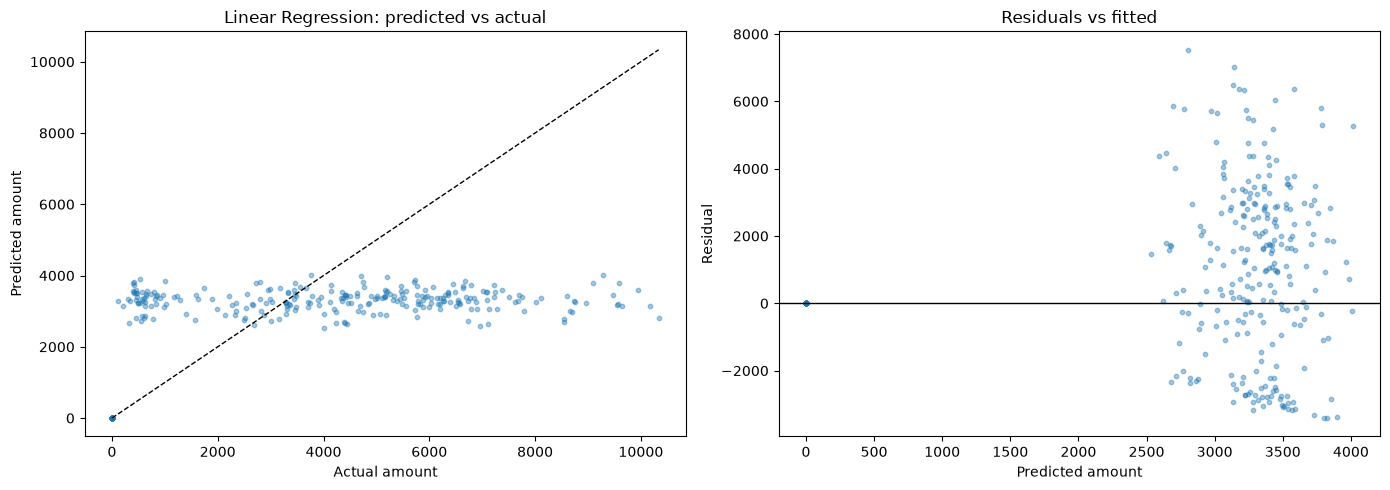

In [15]:
best_name = results_df["MAE"].idxmin()
best_pred = predictions[best_name]
residuals = y_test.values - best_pred
print("Best tabular model by MAE:", best_name)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(y_test, best_pred, s=10, alpha=0.4)
lim = [0, max(y_test.max(), best_pred.max())]
ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set_xlabel("Actual amount"); ax[0].set_ylabel("Predicted amount")
ax[0].set_title(f"{best_name}: predicted vs actual")

ax[1].scatter(best_pred, residuals, s=10, alpha=0.4)
ax[1].axhline(0, color="k", lw=1)
ax[1].set_xlabel("Predicted amount"); ax[1].set_ylabel("Residual")
ax[1].set_title("Residuals vs fitted")

plt.tight_layout()
plt.show()

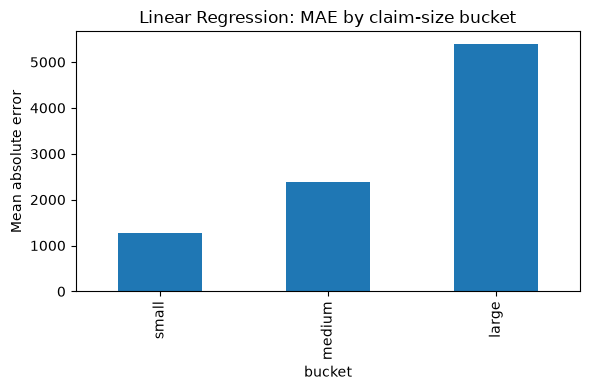

bucket
small     1272.572899
medium    2392.955515
large     5399.632378
Name: abs_err, dtype: float64

In [16]:
bucket = pd.qcut(y_test, q=[0, 0.5, 0.9, 1.0], labels=["small", "medium", "large"], duplicates="drop")
err_df = pd.DataFrame({"bucket": bucket, "abs_err": np.abs(residuals)})
bucket_mae = err_df.groupby("bucket", observed=True)["abs_err"].mean()

plt.figure(figsize=(6, 4))
bucket_mae.plot(kind="bar")
plt.ylabel("Mean absolute error")
plt.title(f"{best_name}: MAE by claim-size bucket")
plt.tight_layout()
plt.show()

bucket_mae

In [17]:
joblib.dump({"Linear Regression": linear_pipe, "Random Forest": rf_pipe, "XGBoost": xgb_pipe},
            MODEL_DIR / "regression_tabular_models.pkl")

test_out = X_test.copy()
test_out["Amount"] = y_test.values
for name, pred in predictions.items():
    test_out[f"pred_{name.replace(' ', '_')}"] = pred
test_out.to_csv(PRED_DIR / "regression_tabular_test_preds.csv", index=False)

print("Saved tabular regression models and predictions.")

Saved tabular regression models and predictions.


The tabular models fix the reference bar. The open question — the core of the project — is whether a purely visual damage signal carries information the policy variables miss. That experiment is notebook 07.